In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')
X_val = np.load('../data/processed/X_val.npy')
y_val = np.load('../data/processed/y_val.npy')
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')

In [3]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

total_fraude = int(y_train.sum())
total_normal = int(len(y_train) - total_fraude)
anomalias_porcentaje = total_fraude / len(y_train)
print(f'Total fraude: {total_fraude}, Total normal: {total_normal}, Porcentaje de anomalias: {anomalias_porcentaje*100:.6f} %')


Total fraude: 394, Total normal: 227451, Porcentaje de anomalias: 0.172925 %


In [ ]:
params = {
    'objective': 'binary:logistic',  
    'eval_metric': 'aucpr',
    'scale_pos_weight': total_normal / total_fraude,
    'max_depth': 6,
    'learning_rate': 0.1
}

In [11]:
evals = [(dtrain, 'train'), (dval, 'validation')]

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50
)

[0]	train-aucpr:0.56370	validation-aucpr:0.48530
[1]	train-aucpr:0.57356	validation-aucpr:0.49660
[2]	train-aucpr:0.61021	validation-aucpr:0.52591
[3]	train-aucpr:0.61538	validation-aucpr:0.52775
[4]	train-aucpr:0.62938	validation-aucpr:0.53081
[5]	train-aucpr:0.62583	validation-aucpr:0.53239
[6]	train-aucpr:0.62729	validation-aucpr:0.52974
[7]	train-aucpr:0.62911	validation-aucpr:0.52813
[8]	train-aucpr:0.63392	validation-aucpr:0.54081
[9]	train-aucpr:0.63509	validation-aucpr:0.53988
[10]	train-aucpr:0.73434	validation-aucpr:0.62581
[11]	train-aucpr:0.82762	validation-aucpr:0.67576
[12]	train-aucpr:0.83159	validation-aucpr:0.67850
[13]	train-aucpr:0.83318	validation-aucpr:0.67921
[14]	train-aucpr:0.83745	validation-aucpr:0.68124
[15]	train-aucpr:0.85855	validation-aucpr:0.70500
[16]	train-aucpr:0.86130	validation-aucpr:0.70531
[17]	train-aucpr:0.86356	validation-aucpr:0.70602
[18]	train-aucpr:0.86405	validation-aucpr:0.70631
[19]	train-aucpr:0.86674	validation-aucpr:0.70797
[20]	train

In [ ]:
probabilidades = model.predict(dtest) # devualve probabilidades de la clase positiva

predicciones = [1 if prob >= 0.45 else 0 for prob in probabilidades]

print(predicciones)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, predicciones))

print("Matriz de Confusión:")
print(confusion_matrix(y_test, predicciones))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.89      0.80      0.84        49

    accuracy                           1.00     28481
   macro avg       0.94      0.90      0.92     28481
weighted avg       1.00      1.00      1.00     28481

Matriz de Confusión:
[[28427     5]
 [   10    39]]


In [27]:
tn, fp, fp, tp = 28427, 5, 10, 39

precision = tp / (tp + fp)
recall = tp / (tp + fn)
print("Precision:", precision)
print("Recall:", recall)

Precision: 0.7959183673469388
Recall: 0.8863636363636364


AUCPR: 0.7058242095974018


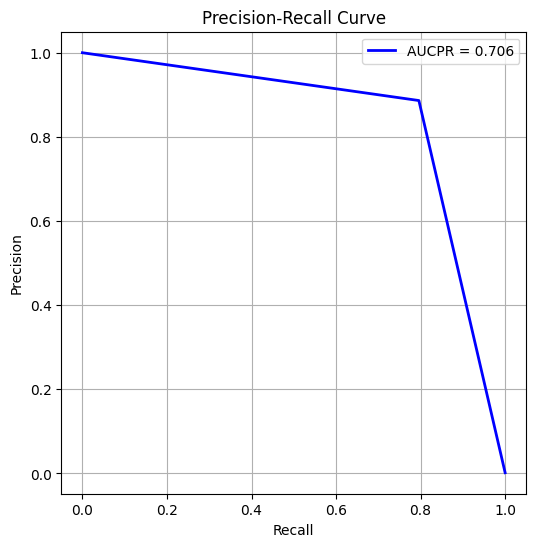

In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, predicciones)
aucpr = average_precision_score(y_test, predicciones)
print("AUCPR:", aucpr)
plt.figure(figsize=(6,6))
plt.plot(recall, precision, color='b', lw=2, label=f'AUCPR = {aucpr:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


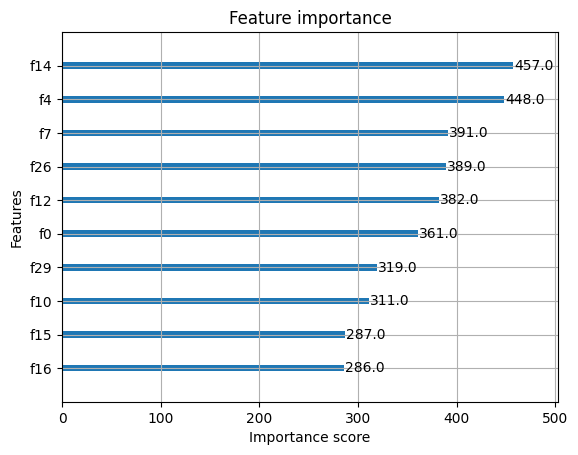

In [15]:
import matplotlib.pyplot as plt

# Graficar las variables más importantes
xgb.plot_importance(model, max_num_features=10) # Mostramos las 10 mejores
plt.show()